---
title: Pauli Correlation Encoding to reduce Maxcut requirements
description: Use Pauli Correlation Encoding to encode optimization problems into qubits with greater efficiency for quantum computation.
---

{/* cspell:ignore lbrack setminus coloneqq rbrack  // latex that isn't being ignored for some reason */}

# Pauli Correlation Encoding to reduce Maxcut requirements

*Usage estimate: 30 minutes on an Eagle r3 processor (NOTE: This is an estimate only. Your runtime might vary.)*



## Background

This tutorial presents *Pauli Correlation Encoding* (PCE) [\[1\]](#references), an approach designed to encode optimization problems into qubits with greater efficiency for quantum computation. PCE maps classical variables in optimization problems to multi-body Pauli-matrix correlations, resulting in a polynomial compression of the problem's space requirements. By employing PCE, the number of qubits needed for encoding is reduced, making it particularly advantageous for near-term quantum devices with limited qubit resources. Furthermore, it is analytically demonstrated that PCE inherently mitigates barren plateaus, offering super-polynomial resilience against this phenomenon. This built-in feature enables unprecedented performance in quantum optimization solvers.



### Overview

The PCE approach consists of three main steps, as illustrated in the Figure 1 from [\[1\]](#references) in below:

1. Encoding the optimization problem into a Pauli correlation space.
2. Solving the problem using a quantum-classical optimization solver.
3. Decoding the solution back to the original optimization space.
   The PCE approach is adaptable to any quantum optimization solver capable of processing Pauli correlation matrices.



![pce-overview.png](https://quantum.cloud.ibm.com/docs/images/tutorials/solving-maxcut-with-reduced-qubit-requirements-using-pauli-correlation-encoding/af2cb835-88db-4a3d-9c86-51424b1a4bd3.avif)



in the Figure 1 from [\[1\]](#references) , Max-Cut problem is used as an example to illustrate the PCE approach. The Max-Cut problem with $m=9$ nodes is encoded into a Pauli correlation space, representing the optimization problem as a correlation matrix, specifically, 2-body Pauli-matrix correlations across $n=3$ qubits $(Q_1, Q_2, Q_3)$. Node colors indicate the Pauli string used for each encoded node.
For example, that node 1, which corresponds to binary variable $x_1$, is encoded by the expectation value of $Z_1 \otimes Z_2 \otimes I_3$, while $x_8$ is encoded by $I_1 \otimes Y_2 \otimes Y_3$.
This corresponds to compressing the problem’s $m$ variables into $ n = O(m^{1/2})$ qubits. More broadly, $k $-body correlations enable polynomial compressions of order $k$. The chosen Pauli set comprises three subsets of mutually-commuting Pauli strings, allowing all $m$ correlations to be experimentally estimated with only three measurement settings.

A loss function $\mathcal{L}$ of Pauli expectation values that imitates the original Max-Cut objective function is constructed. The loss function is then optimized using a quantum-classical optimization solver, such as the  Variational Quantum Eigensolver (VQE).

Once the optimization is complete, the solution is decoded back to the original optimization space, yielding the optimal Max-Cut solution.

## Requirements

Before starting this tutorial, be sure you have the following installed:

* Qiskit SDK v1.0 or later, with [visualization](/docs/api/qiskit/visualization) support
* Qiskit Runtime v0.22 or later (`pip install qiskit-ibm-runtime`)



## Setup



In [ ]:
from itertools import combinations

import numpy as np
import rustworkx as rx
from scipy.optimize import minimize

from qiskit.circuit.library import efficient_su2
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.quantum_info import SparsePauliOp
from qiskit_ibm_runtime import Estimator
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import Session
from rustworkx.visualization import mpl_draw

service = QiskitRuntimeService()
backend = service.least_busy(
    operational=True, simulator=False, min_num_qubits=127
)

In [ ]:
def calc_cut_size(graph, partition0, partition1):
    """Calculate the cut size of the given partitions of the graph."""

    cut_size = 0
    for edge0, edge1 in graph.edge_list():
        if edge0 in partition0 and edge1 in partition1:
            cut_size += 1
        elif edge0 in partition1 and edge1 in partition0:
            cut_size += 1
    return cut_size

## Step 1: Map classical inputs to a quantum problem

### Max-Cut Problem

The Max-Cut problem is a combinatorial optimization problem that is defined on a graph $G = (V, E)$, where $V$ is the set of vertices and $E$ is the set of edges. The goal is to partition the vertices into two sets, $S$ and $V \setminus S$, such that the number of edges between the two sets is maximized.
For the detailed description of the Max-Cut problem, please refer to the ["Quantum approximate optimization algorithm"](./quantum-approximate-optimization-algorithm) tutorial.
Also, the Max-Cut problem is used as an example in the tutorial ["Advanced Techniques for QAOA"](./advanced-techniques-for-qaoa).
In those tutorials, the QAOA algorithm is used to solve the Max-Cut problem.

### Graph -> Hamiltonian

This tutorial uses a random graph with 1000 nodes.

The problem size might be hard to visualize, so below is a graph with 100 nodes. (Rendering a graph with 1,000 nodes directly would make it too dense to see anything!) The graph we are working with is ten times larger.



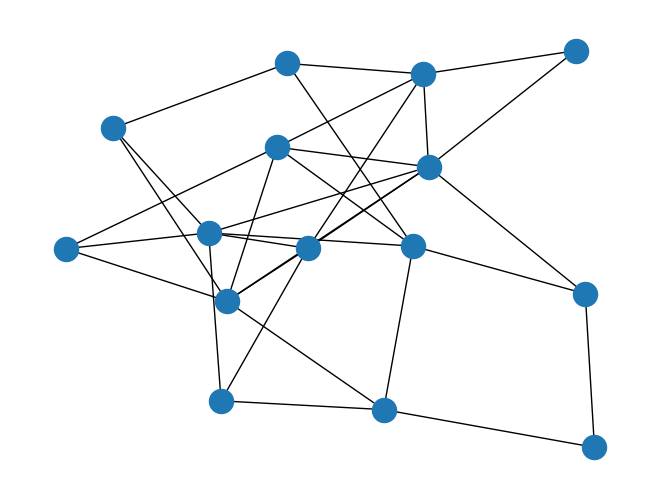

In [ ]:
mpl_draw(rx.undirected_gnp_random_graph(15, 0.3, seed=42))

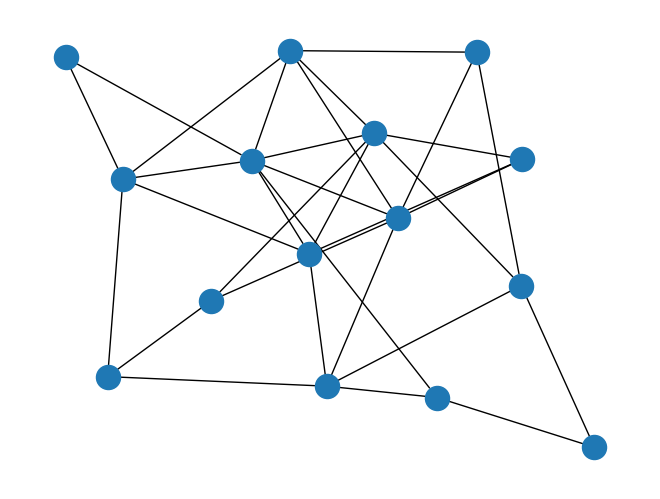

In [ ]:
num_nodes = 15  # Number of nodes in graph
graph = rx.undirected_gnp_random_graph(num_nodes, 0.3, seed=42)
mpl_draw(graph)

In [ ]:
import networkx as nx

nx_graph = nx.Graph() 
nx_graph.add_nodes_from(range(num_nodes)) 

In [ ]:
for edge in graph.edge_list():
    nx_graph.add_edge(edge[0], edge[1])

In [ ]:
curr_cut_size, partition = nx.approximation.one_exchange(nx_graph, seed=1) # Initial partition using one-exchange heuristic
print(f"Initial cut size: {curr_cut_size}")
print(f"Initial partition: {partition} ")

Initial cut size: 26
Initial partition: ({1, 2, 3, 4, 5, 6, 7, 12}, {0, 8, 9, 10, 11, 13, 14}) 


We encode the graph with 1000 nodes into 2-body Pauli-matrix correlations across 100 qubits. The graph is represented as a correlation matrix, where each node is encoded by a Pauli string. The sign of the expectation value of the Pauli string indicates the partition of the node. For example, node 0 is encoded by a Pauli string, $\prod_0 = I_{19} \otimes ... I_2 \otimes X_1 \otimes X_0$. The sign of the expectation value of this Pauli string indicates the partition of node 0. We define a *Pauli-correlation encoding* (PCE) relative to $\prod$ as

$x_i \coloneqq \textit{sgn}(\langle\prod_i \rangle)$

where $x_i$ is the partition of node $i$ and $\langle \prod_i \rangle \coloneqq  \langle \psi |\prod_i| \psi \rangle $ is the expectation value of the Pauli string encoding node $i$ over a quantum state $|\psi \rangle$.



Now, let's encode the graph into a Hamiltonian using PCE.
We divide the nodes into three sets: $S_1$, $S_2$, and $S_3$.
Then, we encode the nodes in each set using the Pauli strings with $X$, $Y$, and $Z$, respectively.



In [ ]:
num_qubits = 4

list_size = num_nodes // 3
node_x = [i for i in range(list_size)]
node_y = [i for i in range(list_size, 2 * list_size)]
node_z = [i for i in range(2 * list_size, num_nodes)]

print("List 1:", node_x)
print("List 2:", node_y)
print("List 3:", node_z)

List 1: [0, 1, 2, 3, 4]
List 2: [5, 6, 7, 8, 9]
List 3: [10, 11, 12, 13, 14]


In [ ]:
def build_pauli_correlation_encoding(pauli, node_list, n, k=2):
    pauli_correlation_encoding = []
    for idx, c in enumerate(combinations(range(n), k)):      # Generate all combinations of qubits for the given k
        if idx >= len(node_list):      # Only consider combinations up to the length of the node list
            break
        paulis = ["I"] * n          # Initialize all qubits to identity
        paulis[c[0]], paulis[c[1]] = pauli, pauli    # Set the specified Pauli operator on the selected qubits
        pauli_correlation_encoding.append(("".join(paulis)[::-1], 1))    # Append the Pauli string to the encoding list

    hamiltonian = []
    for pauli, weight in pauli_correlation_encoding:
        hamiltonian.append(SparsePauliOp.from_list([(pauli, weight)]))

    return hamiltonian


pauli_correlation_encoding_x = build_pauli_correlation_encoding(
    "X", node_x, num_qubits
)
pauli_correlation_encoding_y = build_pauli_correlation_encoding(
    "Y", node_y, num_qubits
)
pauli_correlation_encoding_z = build_pauli_correlation_encoding(
    "Z", node_z, num_qubits
)

## Step 2: Optimize problem for quantum hardware execution

### Quantum circuit

Here, the state $|\psi \rangle$ is parameterized with $\mathbf{\theta}$, and we optimize these parameters $\mathbf{\theta}$ using a variational approach.
This tutorial employs the `efficient_su2` ansatz for our variational algorithm due to its expressive capabilities and ease of implementation.
We also use the relaxed loss function, which will be introduced later in this tutorial.
As a result, we can address large-scale problems with fewer qubits and shallower circuit depths.



In [ ]:
# Build the quantum circuit
qc = efficient_su2(num_qubits, ["ry", "rz"], reps=2)    # Create a parameterized quantum circuit with 2 repetitions of Ry and Rz gates


In [ ]:
# Optimisation hardware : on optimise la structure du circuit pour le backend cible

pm = generate_preset_pass_manager(optimization_level=3, backend=backend)  # Generate a pass manager with optimization level 3 for the specified backend
# un pass manager est un compilateur
qc = pm.run(qc)   # Optimize the quantum circuit using the pass manager

### Loss function

For the loss function $\mathcal{L}$, we use a relaxation of the Max-Cut objective function as described in [\[1\]](#references), which is defined as $\mathcal{V}(\mathbf{x}) \coloneqq \sum_{(i, j) \in E} W_{i, j}(1-x_i x_j)$. Here, $W_{i, j}$ denotes the weight of the edge $(i, j)$, and $x_i$ represents the partition of node $i$.
The loss function  $\mathcal{L}$ is given by:

$\mathcal{L}\coloneqq \sum_{(i, j) \in E} W_{i, j} \text{tanh} (\alpha \langle\prod_i \rangle) \text{tanh} (\alpha \langle\prod_j \rangle) + \mathcal{L}^{(\text{reg})}$

where the Max-Cut objective function is replaced by the smooth hyperbolic tangents of the expectation values of the Pauli strings encoding the nodes. The regularization term $\mathcal{L}^{(\text{reg})}$ and the rescaling factor $\alpha$, proportional to the number of qubits, are introduced to improve the solver's performance.

The regularization term is defined as:

$\mathcal{L}^{(\text{reg})}$ is defined as $\mathcal{L}^{(\text{reg})} \coloneqq \beta \nu \lbrack \frac{1}{m} \sum_{i \in V} \text{tanh} (\alpha \langle\prod_i \rangle)^2 \rbrack ^2$

where $\beta=1/2$, $\nu = |E|/2 + (m -1) /4$, and $m$ is the number of nodes in the graph.



In [ ]:
def loss_func_estimator(x, ansatz, hamiltonian, estimator, graph):
    """
    Calculates the specified loss function for the given ansatz, Hamiltonian, and graph.

    The expectation values of each Pauli string in the Hamiltonian are first obtained
    by running the ansatz on the quantum backend. These expectation values are then
    passed through the nonlinear function tanh(alpha * prod_i). The loss function is
    subsequently computed from these transformed values.
    """
    job = estimator.run(
        [
            (ansatz, hamiltonian[0], x),
            (ansatz, hamiltonian[1], x),
            (ansatz, hamiltonian[2], x),
        ]
    )
    result = job.result()

    # calculate the loss function
    node_exp_map = {}
    idx = 0
    for r in result:
        for ev in r.data.evs:
            node_exp_map[idx] = ev
            idx += 1

    loss = 0
    alpha = num_qubits
    for edge0, edge1 in graph.edge_list():
        loss += np.tanh(alpha * node_exp_map[edge0]) * np.tanh(
            alpha * node_exp_map[edge1]
        )

    regulation_term = 0
    for i in range(len(graph.nodes())):
        regulation_term += np.tanh(alpha * node_exp_map[i]) ** 2
    regulation_term = regulation_term / len(graph.nodes())
    regulation_term = regulation_term**2
    beta = 1 / 2
    v = len(graph.edges()) / 2 + (len(graph.nodes()) - 1) / 4
    regulation_term = beta * v * regulation_term

    loss = loss + regulation_term

    global experiment_result
    print(f"Iter {len(experiment_result)}: {loss}")
    experiment_result.append({"loss": loss, "exp_map": node_exp_map})
    return loss

## Step 3: Execute using Qiskit primitives



In this tutorial, we set `max_iter=50` for the optimization loop for demonstration purpose. If we increase the number of iterations, we can expect better results.



In [ ]:
pce = []
pce.append(
    [op.apply_layout(qc.layout) for op in pauli_correlation_encoding_x]  
)
pce.append(
    [op.apply_layout(qc.layout) for op in pauli_correlation_encoding_y]
)
pce.append(
    [op.apply_layout(qc.layout) for op in pauli_correlation_encoding_z]
)

In [ ]:
# Run the optimization without Session (for open plan)
from qiskit_ibm_runtime import Estimator
estimator = Estimator(backend)  # Use the open plan simulator
experiment_result = []

def loss_func(x):
    return loss_func_estimator(
        x, qc, [pce[0], pce[1], pce[2]], estimator, graph
    )

np.random.seed(42)
initial_params = np.random.rand(qc.num_parameters)
result = minimize(
    loss_func, initial_params, method="COBYLA", options={"maxiter": 10}
    )
print(result)

c:\Users\blaiz\AppData\Local\Programs\Python\Python312\Lib\site-packages\qiskit_ibm_runtime\qiskit_runtime_service.py:1210: UserWarning: This instance has met its usage limit. Workloads will not run until time is made available. Check https://quantum.cloud.ibm.com/instances/crn%3Av1%3Abluemix%3Apublic%3Aquantum-computing%3Aus-east%3Aa%2Ffa04d9576ae344d9af76993b284f591f%3Aa17376f5-5e43-4cbd-b645-3a8919749c4f%3A%3A for more details.
  warnings.warn(


KeyboardInterrupt: 

## Step 4: Post-process and return result in desired classical format

The partitions of the nodes are determined by evaluating the sign of the expectation values of the Pauli strings that encode the nodes.



In [ ]:
# Calculate the partitions based on the final expectation values
# If the expectation value is positive, the node belongs to partition 0 (par0)
# Otherwise, the node belongs to partition 1 (par1)

par0, par1 = set(), set()

for i in experiment_result[-1]["exp_map"]:
    if experiment_result[-1]["exp_map"][i] >= 0:
        par0.add(i)
    else:
        par1.add(i)
print(par0, par1)

IndexError: list index out of range

We can calculate the cut size of the Max-Cut problem using the partitions of the node.



In [ ]:
cut_size = calc_cut_size(graph, par0, par1)
print(f"Cut size: {cut_size}")

Cut size: 10


Once the training is complete, we perform one round of single-bit swap search to improve the solution as a classical post-processing step.
In this process, we swap the partitions of two nodes and evaluate the cut size. If the cut size is improved, we keep the swap. We repeat this process for all possible pairs of nodes connected by an edge.



In [ ]:
best_bits = []
cur_bits = []

for i in experiment_result[-1]["exp_map"]:
    if experiment_result[-1]["exp_map"][i] >= 0:
        cur_bits.append(1)
    else:
        cur_bits.append(0)
print(cur_bits)

[1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1]


In [ ]:
# Swap the partitions and calculate the cut size
best_cut = 0
for edge0, edge1 in graph.edge_list():
    swapped_bits = cur_bits.copy()
    swapped_bits[edge0], swapped_bits[edge1] = (
        swapped_bits[edge1],
        swapped_bits[edge0],
    )

    cur_partition = [set(), set()]
    for i, bit in enumerate(swapped_bits):
        if bit > 0:
            cur_partition[0].add(i)
        else:
            cur_partition[1].add(i)
    cut_size = calc_cut_size(graph, cur_partition[0], cur_partition[1])
    if best_cut < cut_size:
        best_cut = cut_size
        best_bits = swapped_bits

print(best_cut, best_bits)

10 [1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1]


## References

\[1] Sciorilli, M., Borges, L., Patti, T. L., García-Martín, D., Camilo, G., Anandkumar, A., & Aolita, L. (2024). Towards large-scale quantum optimization solvers with few qubits. arXiv preprint arXiv:2401.09421.



## Tutorial survey

Please take this short survey to provide feedback on this tutorial. Your insights will help us improve our content offerings and user experience.

[Link to survey](https://your.feedback.ibm.com/jfe/form/SV_8ANZAlsKSFf6DA2)



© IBM Corp., 2017-2026